In [2]:
import pandas as pd
df = pd.read_csv('insurance_data.csv')
print(df['CLAIM_STATUS'].value_counts(normalize=True)) # Check the ratio

CLAIM_STATUS
A    0.9497
D    0.0503
Name: proportion, dtype: float64


In [3]:
missing_data = df.isnull().sum()
print("\n--- Missing Values ---")
print(missing_data[missing_data > 0])


--- Missing Values ---
ADDRESS_LINE2               8505
CITY                          54
CUSTOMER_EDUCATION_LEVEL     529
AUTHORITY_CONTACTED         1945
INCIDENT_CITY                 46
VENDOR_ID                   3245
dtype: int64


In [4]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


--- Class Distribution ---


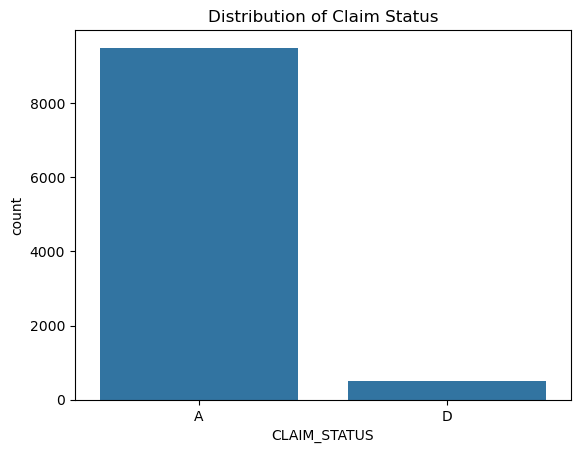

In [6]:
print("\n--- Class Distribution ---")
sns.countplot(x='CLAIM_STATUS', data=df)
plt.title('Distribution of Claim Status')
plt.show()

In [7]:
df.head(10)

,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472
5,2020-06-01 00:00:00,TXN00000006,A00003571,PLC00007244,2012-12-28,2020-05-20,2020-05-25,Life,87.02,63000,...,A,Major Loss,Ambulance,0,1,AZ,Glendale,0,AGENT00402,NaN
6,2020-06-01 00:00:00,TXN00000007,A00007245,PLC00002796,2012-10-26,2020-05-13,2020-05-18,Health,197.23,3000,...,A,Major Loss,Police,1,1,CT,Manchester,10,AGENT00322,VNDR00150
7,2020-06-01 00:00:00,TXN00000008,A00004301,PLC00002925,2018-12-30,2020-05-14,2020-05-19,Motor,83.77,8000,...,A,Total Loss,Police,0,1,FL,Panama City Beach,10,AGENT00152,VNDR00326
8,2020-06-01 00:00:00,TXN00000009,A00004671,PLC00006886,2019-06-27,2020-05-21,2020-05-26,Motor,82.14,5000,...,A,Major Loss,Police,0,1,AZ,Glendale,22,AGENT00450,VNDR00437
9,2020-06-01 00:00:00,TXN00000010,A00002020,PLC00007657,2015-12-19,2020-05-15,2020-05-20,Travel,71.29,4000,...,A,Major Loss,NaN,0,0,CA,San Leandro,4,AGENT00682,NaN


In [8]:
# --- STEP 1: FIX TARGET ---
# Darori t-convertiha l-arkam qbel get_dummies
df['CLAIM_STATUS'] = df['CLAIM_STATUS'].map({'A': 0, 'D': 1})

# --- STEP 2: CLEANING ---
cols_to_drop = [
    'TXN_DATE_TIME', 'TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER', 
    'CUSTOMER_NAME', 'ADDRESS_LINE1', 'ADDRESS_LINE2', 'SSN', 
    'AGENT_ID', 'VENDOR_ID', 'CITY', 'INCIDENT_CITY',
    'ACCT_NUMBER', 'ROUTING_NUMBER', 'POSTAL_CODE',
    'POLICY_EFF_DT'
]
df_clean = df.drop(columns=cols_to_drop)


# --- STEP 3: IMPUTATION CONDITIONEL ---
# 3emmar l-khwa f-l-columns li bqaw

df_clean['AUTHORITY_CONTACTED'] = df_clean.groupby('INCIDENT_SEVERITY')['AUTHORITY_CONTACTED'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "None")
)
df_clean['CUSTOMER_EDUCATION_LEVEL'] = df_clean['CUSTOMER_EDUCATION_LEVEL'].fillna(df_clean['CUSTOMER_EDUCATION_LEVEL'].mode()[0])



# --- STEP 4: ENCODING ---
df_final = pd.get_dummies(df_clean, drop_first=True)

# --- STEP 5: SPLIT X & y ---
X = df_final.drop(['CLAIM_STATUS'], axis=1)
y = df_final['CLAIM_STATUS']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- STEP 6: SCALING/NORMALISATION--- ki wahad lina les nombre f lprogramme bach l  computer ma i3tech ahamia les coloumn li 3ndhom ar9am kbar
#mohim m3a logistic regression SMOTE ay model kayhsab distance
#ka ndiro had l'etape 9bl man split bach l model ma ichofch data man test known as data leakage
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Kolchi khdem! Columns 3ndek daba huma:", X.columns.tolist()[:5], "... etc")

✅ Kolchi khdem! Columns 3ndek daba huma: ['PREMIUM_AMOUNT', 'CLAIM_AMOUNT', 'AGE', 'TENURE', 'NO_OF_FAMILY_MEMBERS'] ... etc


In [9]:
from imblearn.over_sampling import SMOTE
''' La technique SMOTE a été appliquée uniquement sur 
l’ensemble d’entraînement afin de corriger le déséquilibre des 
classes et améliorer le rappel de la classe frauduleuse. KA TKHL9 LINA DATA STINA3IA O ILA TB9NAHA 3LA TEST GHADI NTEHO F DATA LEAKAGE '''
smote = SMOTE(
    sampling_strategy=0.3,  # fraude تولي ~30% فقط
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
#oversampling tb9at hna smote.fit_resample(X_train_scaled, y_train)


In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000) # ka n3tewh wa9t bach yt3lm mzyane b max_iter
lr.fit(X_train_smote, y_train_smote)
#HNA THNA F MOCHKIL DIAL Underfitting structurel meme si drna normalisation o smote

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=6, random_state=42)#شحال من سؤال تقدر الشجرة تسول قبل ما تعطي القرار, 🔹 random_state=42 باش النتائج تكون قابلة للإعادة
dt.fit(X_train_smote, y_train_smote)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,# 50 arbre learn independament
    max_depth=12,#ch7al ma so2al 9bl ma iykhd decision preserve overfitting
    class_weight="balanced",
    min_samples_leaf=5,
    random_state=42,#same result in 42 try
    n_jobs=-1# improve CPU FOR FAST TRANING
)

rf.fit(X_train_smote, y_train_smote)


In [ ]:
# overfitting tjanabnah b les attribut li ka nzido l dt o rf max_depth.... 
#prc ka nhado l3om9 ma ka nkhaliwch lmodel ihfd data

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    print("\n", name)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_proba >= 0.3).astype(int)  # threshold مهبط
    else:
        y_pred = model.predict(X_test_scaled)
    #ka nfdlo hna nmsko fraude meme si nghlto f non-fraude

    #y_pred = model.predict(X_test_scaled)
     #ki 3te 9arar 3la data 3mro chfha f traning "X_test_scaled" 3la hasab model 
    print(confusion_matrix(y_test, y_pred))#ka n9rno y_pred list ki contient le resulta fraud(1) ou nonfraude(0) li predetah m3a li f test(l7a9i9a)
    print(classification_report(y_test, y_pred, zero_division=0))# ki 3tina precision ....
    if hasattr(model, "predict_proba"):
        roc = roc_auc_score(y_test, y_proba)
        print("ROC-AUC:", round(roc, 3))



 Logistic Regression
[[1506  393]
 [  82   19]]
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      1899
           1       0.05      0.19      0.07       101

    accuracy                           0.76      2000
   macro avg       0.50      0.49      0.47      2000
weighted avg       0.90      0.76      0.82      2000

ROC-AUC: 0.5

 Decision Tree
[[1873   26]
 [ 101    0]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1899
           1       0.00      0.00      0.00       101

    accuracy                           0.94      2000
   macro avg       0.47      0.49      0.48      2000
weighted avg       0.90      0.94      0.92      2000

ROC-AUC: 0.484

 Random Forest
[[1727  172]
 [  91   10]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1899
           1       0.05      0.10      0.07       101

    accuracy       